# Guided Numeric Exploration — Powerlifting Database
_OpenPowerlifting static copy: lifts, Wilks, equipment, and meet context_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [dansbecker/powerlifting-database](https://www.kaggle.com/datasets/dansbecker/powerlifting-database)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Strength & Missingness](#Univariate)** <br>
**4. [Sex × Equipment](#SexEquip)** <br>
**5. [Bodyweight Allometry](#Allometry)** <br>
**6. [Meet Context: Federation & Time](#Meets)** <br>
**7. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **static OpenPowerlifting extract** (~386k lift rows + ~8.5k meets) frozen for reproducible Kaggle Learn work. Lifter results join to meets on `MeetID` for federation, date, and country.

Missingness is severe for `Age` (~62%) and nontrivial for individual lifts / totals. I filter to complete outcomes **per section** rather than imputing bodyweight, age, or kilos.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, PCA), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "dansbecker/powerlifting-database"
OPL_NAME = "openpowerlifting.csv"
MEETS_NAME = "meets.csv"
OPL_COLS = [
    "MeetID", "Name", "Sex", "Equipment", "Age", "Division", "BodyweightKg", "WeightClassKg",
    "Squat4Kg", "BestSquatKg", "Bench4Kg", "BestBenchKg", "Deadlift4Kg", "BestDeadliftKg",
    "TotalKg", "Place", "Wilks",
]
MEET_COLS = ["MeetID", "MeetPath", "Federation", "Date", "MeetCountry", "MeetState", "MeetTown", "MeetName"]


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(OPL_NAME))
        assert hits, "openpowerlifting.csv not under /kaggle/input"
        return hits[0].parent
    local_dir = Path("data") / "powerlifting-database"
    if (local_dir / OPL_NAME).exists() and (local_dir / MEETS_NAME).exists():
        return local_dir
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(OPL_NAME))
    assert hits, f"expected {OPL_NAME} under {root}"
    return hits[0].parent


root = resolve_dataset_root()
print("Dataset root:", root)
opl = pd.read_csv(root / OPL_NAME, low_memory=False)
meets = pd.read_csv(root / MEETS_NAME, low_memory=False)
assert set(OPL_COLS) <= set(opl.columns)
assert set(MEET_COLS) <= set(meets.columns)
assert len(opl) > 300_000
assert opl["MeetID"].isin(meets["MeetID"]).all()

df = opl.merge(meets, on="MeetID", how="inner", validate="many_to_one")
assert len(df) == len(opl)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year"] = df["Date"].dt.year

null_rate = df[["Age", "BestSquatKg", "BestBenchKg", "BestDeadliftKg", "TotalKg", "Wilks", "BodyweightKg"]].isna().mean()
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Merged dimension: {} Rows, {} Columns".format(*df.shape))
print("Null rates:\n", null_rate.round(3).sort_values(ascending=False))
print("Sex:", df["Sex"].value_counts().to_dict())
print("Equipment top:", df["Equipment"].value_counts().head().to_dict())


  0%|          | 0.00/8.85M [00:00<?, ?B/s]

 11%|█▏        | 1.00M/8.85M [00:00<00:04, 1.97MB/s]

 23%|██▎       | 2.00M/8.85M [00:00<00:02, 2.71MB/s]

 34%|███▍      | 3.00M/8.85M [00:01<00:01, 3.39MB/s]

 45%|████▌     | 4.00M/8.85M [00:01<00:01, 3.28MB/s]

...

100%|██████████| 8.85M/8.85M [00:02<00:00, 3.60MB/s]

100%|██████████| 8.85M/8.85M [00:02<00:00, 3.24MB/s]

Extracting files...


Dataset root: /Users/nicapotato/.cache/kagglehub/datasets/dansbecker/powerlifting-database/versions/1


Merged dimension: 386414 Rows, 25 Columns
Null rates:
 Age               0.619
BestSquatKg       0.229
BestDeadliftKg    0.177
BestBenchKg       0.078
Wilks             0.063
TotalKg           0.060
BodyweightKg      0.006
dtype: float64
Sex: {'M': 299045, 'F': 87369}
Equipment top: {'Raw': 186317, 'Single-ply': 144406, 'Wraps': 46108, 'Multi-ply': 9576, 'Straps': 7}


**Code Explanation and Reasoning:** <br>
Meet context is joined many-to-one on `MeetID` with a validate check. Null rates are printed up front so later filters are honest about who remains in each analysis slice.


In [3]:
df.sample(5, random_state=7)


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName,year
67801,1514,Mohaned Abujennah,M,Raw,NaN,M-O,65.20,66,NaN,172.50,NaN,115.00,NaN,210.00,497.50,1,394.60,irishpf/1711,IrishPF,2017-12-10,Ireland,NaN,NaN,December Last Chance 2017,2017
44831,1233,Sean Kilbride,M,Raw,NaN,S,71.15,74,NaN,165.00,NaN,125.00,NaN,195.00,485.00,2,359.00,epa/1401,EPA,2014-08-16,England,NaN,Moulton,All England Powerlifting Championships 2014,2014
34232,1026,Rob Truchon,M,Raw,NaN,Master 1,92.00,93,NaN,NaN,NaN,105.00,NaN,NaN,105.00,2,66.30,cpu/2015-04-06-36300976,CPU,2015-04-06,Canada,NL,St. John's,2015 Canadian Championship,2015
195222,5986,Cody Ragsdale,M,Single-ply,NaN,Boys,108.77,110,NaN,165.56,NaN,99.79,NaN,158.76,424.11,4,250.46,thspa/2613,THSPA,2016-02-18,USA,TX,Frisco,Frisco ISD District Meet,2016
1451,26,Jessica Wilkins,F,Wraps,NaN,DT - Open,54.98,56,NaN,97.50,NaN,47.50,NaN,127.50,272.50,3,325.28,apa/1602,APA,2016-04-16,USA,OR,Clackamas,Elite Spring Challenge District 7 Regionals,2016


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False).head(15))
df[["BodyweightKg", "BestSquatKg", "BestBenchKg", "BestDeadliftKg", "TotalKg", "Wilks", "Age"]].describe().T.round(2)


,Column,Unique,Null
8,Squat4Kg,439,385171
10,Bench4Kg,527,384452
12,Deadlift4Kg,574,383614
4,Age,168,239267
22,MeetTown,1540,94000
9,BestSquatKg,1508,88343
21,MeetState,81,72143
13,BestDeadliftKg,1386,68567
11,BestBenchKg,1471,30050
16,Wilks,64828,24220


,count,mean,std,min,25%,50%,75%,max
BodyweightKg,384012.0,86.93,23.14,15.88,70.30,83.20,100.00,242.40
BestSquatKg,298071.0,176.57,69.22,-477.50,127.50,174.63,217.72,573.79
BestBenchKg,356364.0,118.35,54.85,-522.50,79.38,115.00,150.00,488.50
BestDeadliftKg,317847.0,195.04,61.58,-410.00,147.50,195.00,238.14,460.40
TotalKg,363237.0,424.00,196.36,11.00,272.16,424.11,565.00,1365.31
Wilks,362194.0,301.08,116.36,13.73,237.38,319.66,379.29,779.38
Age,147147.0,31.67,12.90,5.00,22.00,28.00,39.00,95.00


**Interpretation** <br>
Men and Raw / Single-ply rows dominate. Age is mostly missing — age analyses must shrink to the observed subset. Fourth-attempt columns are sparse by design and not primary outcomes here.


# **3. Univariate Strength & Missingness:** <a id="Univariate"></a>


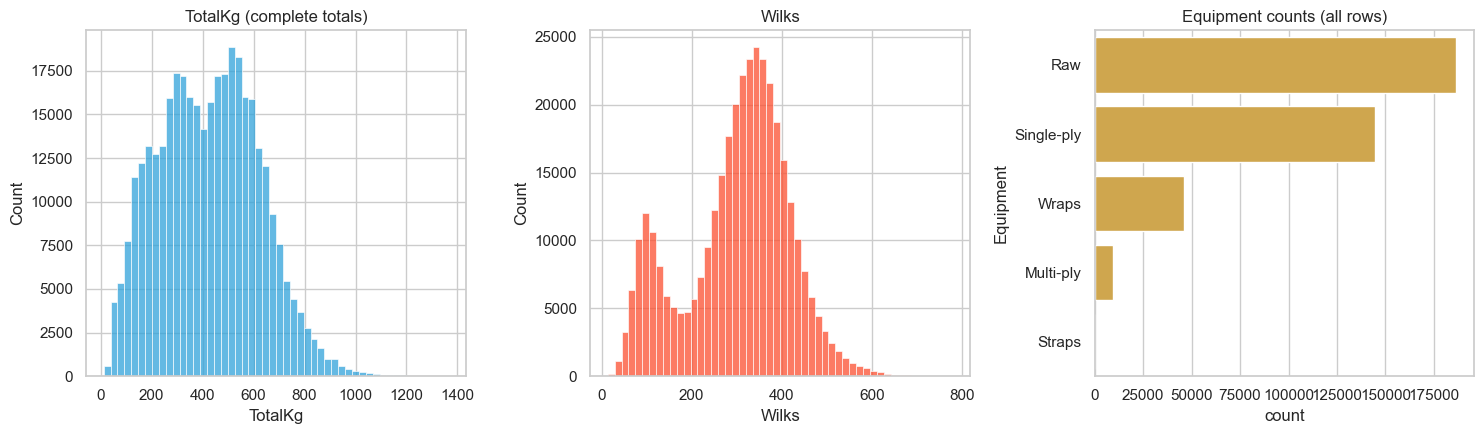

Complete TotalKg+Wilks+BW rows: 362,194 / 386,414


In [5]:
complete = df.dropna(subset=["TotalKg", "Wilks", "BodyweightKg"]).copy()
assert len(complete) > 100_000, len(complete)
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(complete["TotalKg"], bins=50, ax=ax[0], color="#30a2da")
ax[0].set_title("TotalKg (complete totals)")
sns.histplot(complete["Wilks"], bins=50, ax=ax[1], color="#fc4f30")
ax[1].set_title("Wilks")
sns.countplot(data=df, y="Equipment", order=df["Equipment"].value_counts().index, ax=ax[2], color="#e5ae38")
ax[2].set_title("Equipment counts (all rows)")
plt.tight_layout()
plt.show()
print("Complete TotalKg+Wilks+BW rows:", f"{len(complete):,} / {len(df):,}")


**How to Interpret:** <br>
Totals and Wilks are the comparable strength outcomes when present. Equipment counts remind you that gear classes are uneven — always stratify before declaring 'stronger equipment.'


# **4. Sex × Equipment:** <a id="SexEquip"></a>


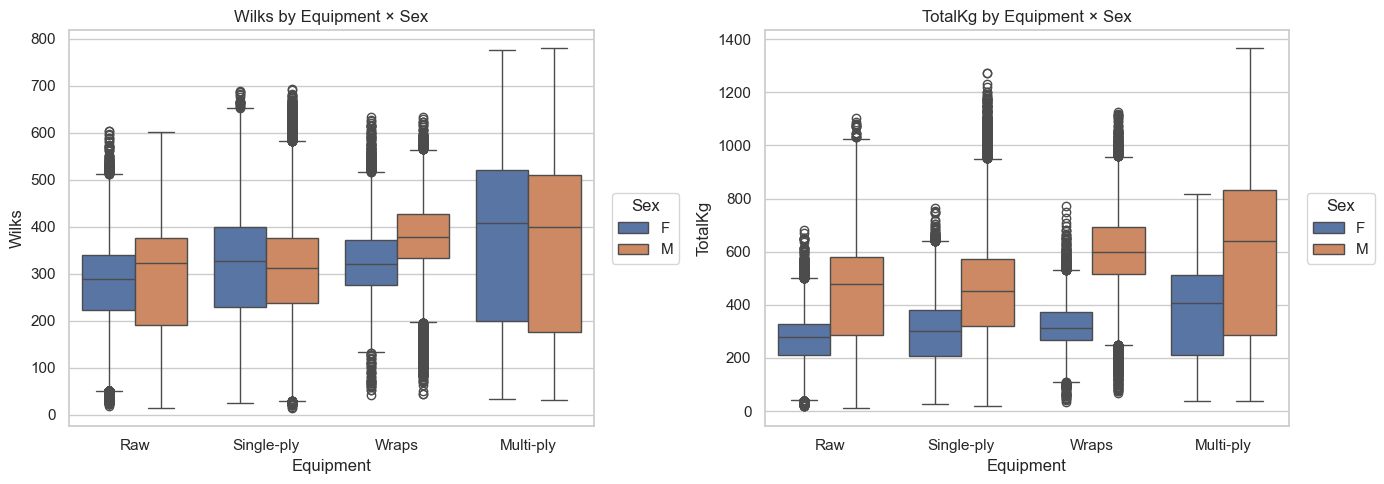

Wilks  TotalKg
Sex Equipment                 
F   Raw         288.5    277.5
    Single-ply  325.9    302.5
    Wraps       320.7    313.0
    Multi-ply   408.5    407.5
M   Raw         321.6    480.0
    Single-ply  311.8    453.6
    Wraps       378.9    600.0
    Multi-ply   398.6    639.6

In [6]:
equip_keep = [e for e in ["Raw", "Single-ply", "Wraps", "Multi-ply"] if e in set(complete["Equipment"])]
sub = complete[complete["Equipment"].isin(equip_keep)]
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=sub, x="Equipment", y="Wilks", hue="Sex", order=equip_keep, ax=ax[0])
ax[0].set_title("Wilks by Equipment × Sex")
ax[0].legend(title="Sex", bbox_to_anchor=(1.02, 0.5), loc="center left")
sns.boxplot(data=sub, x="Equipment", y="TotalKg", hue="Sex", order=equip_keep, ax=ax[1])
ax[1].set_title("TotalKg by Equipment × Sex")
ax[1].legend(title="Sex", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()
display(sub.groupby(["Sex", "Equipment"])[["Wilks", "TotalKg"]].median().reindex(equip_keep, level=1).round(1))


**How to Interpret:** <br>
Wilks attempts bodyweight-adjusted comparison; TotalKg is raw load. Equipment gaps (especially Multi-ply) are expected — they are different sports gear classes, not a fairness ranking.


# **5. Bodyweight Allometry:** <a id="Allometry"></a>


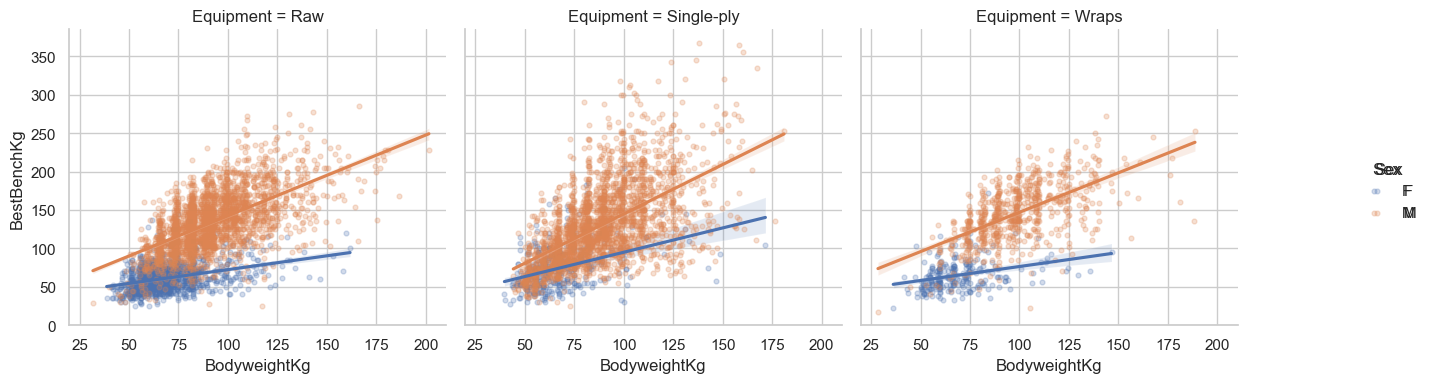

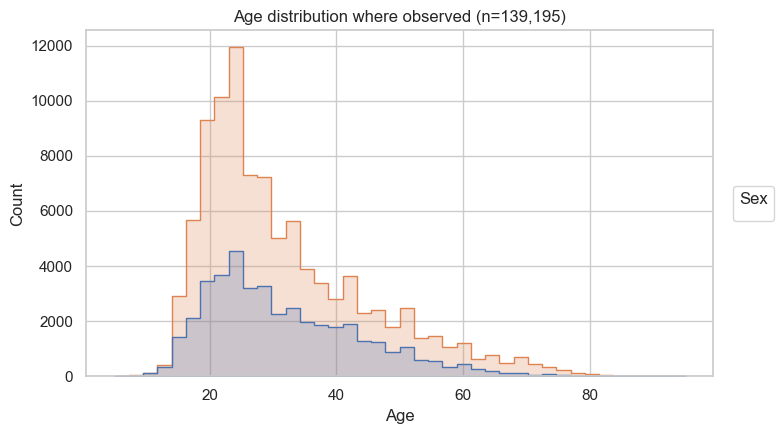

In [7]:
sample = sub.sample(min(8000, len(sub)), random_state=7)
g = sns.lmplot(
    data=sample, x="BodyweightKg", y="BestBenchKg", hue="Sex",
    col="Equipment", col_order=equip_keep[:3],
    scatter_kws={"alpha": 0.25, "s": 12}, height=4, aspect=1.0,
)
g.add_legend(title="Sex")
# move seaborn facet legend to the right of the grid
sns.move_legend(g, "center left", bbox_to_anchor=(1.02, 0.5))
plt.show()

age_df = complete.dropna(subset=["Age"])
assert len(age_df) > 10_000
f, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=age_df, x="Age", hue="Sex", bins=40, element="step", ax=ax)
ax.set_title(f"Age distribution where observed (n={len(age_df):,})")
ax.legend(title="Sex", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Bench vs bodyweight clouds show allometric scaling within sex/equipment. Age plots use the minority of rows with Age filled — do not generalize age curves to the full database.


# **6. Meet Context: Federation & Time:** <a id="Meets"></a>


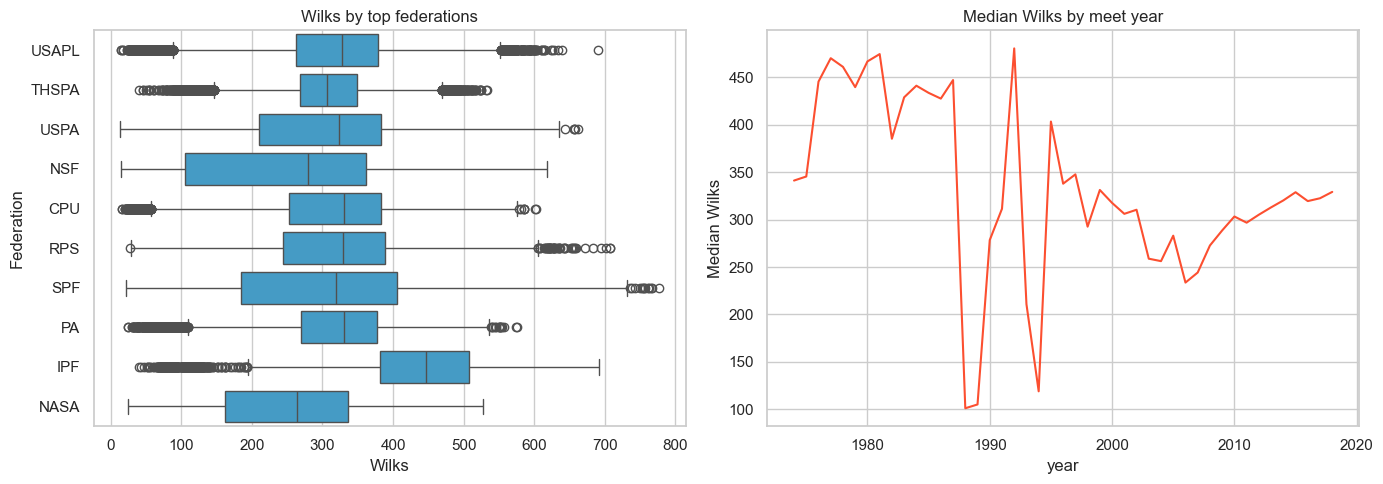

,meets_rows
MeetCountry,
USA,274855
Canada,33235
Norway,31596
Australia,15157
Russia,5869
New Zealand,5711
UK,2982
Czechia,2066
Finland,1759


In [8]:
top_fed = df["Federation"].value_counts().head(10).index
fed = complete[complete["Federation"].isin(top_fed)]
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=fed, y="Federation", x="Wilks",
    order=list(top_fed), ax=ax[0], color="#30a2da",
)
ax[0].set_title("Wilks by top federations")
year_med = (
    complete.dropna(subset=["year"])
    .groupby("year")["Wilks"]
    .median()
)
year_med.plot(ax=ax[1], color="#fc4f30")
ax[1].set_title("Median Wilks by meet year")
ax[1].set_ylabel("Median Wilks")
plt.tight_layout()
plt.show()
display(df["MeetCountry"].value_counts().head(12).to_frame("meets_rows"))


**How to Interpret:** <br>
Federation boxes mix different testing rules, eras, and athlete pools — descriptive, not a federation ranking. Year medians can drift with database coverage, not only with 'athletes getting stronger.'


# **7. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A large static OpenPowerlifting snapshot joined to meet metadata, with honest sparse Age and lift fields.

**Working takeaways:** <br>
- Stratify by Sex and Equipment before comparing totals or Wilks.
- Never impute Age or missing lifts for headline stats.
- Meet federation/year trends need coverage caveats.

**Open follow-ups:** <br>
- Lifter career trajectories via Name + federation filters.
- Weight-class normalized lift ratios (bench/squat/deadlift shares).
